In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

## run simulations


In [2]:
efficiency_per_guide = [0.1, 0.1, 0.9, 0.9]
# efficiency = [0.1, 0.2, 0.5, 0.9]

In [3]:
import os

import jax.numpy as jnp
from jax.random import PRNGKey
from numpyro.infer import Predictive

from perturbo._jax_utils import run_mcmc, run_svi, generate_guide_arrays
from perturbo._jax_module import perturbseq_model, perturbseq_guide_autonormal

n_elements = 11
n_control = 1000
n_guides_per_element = 1
n_guides = n_elements * n_guides_per_element
n_cells_per_guide = 50
gene_mean = 1
log2_fc = jnp.linspace(-1, 1, num=n_elements)
# log2_fc = jnp.zeros(n_elements)

gene_disp = 5
efficiency = jnp.full(n_guides, 0.99)
random_seed = 0
num_samples = 1000
guide_obs, guide_target_elements = generate_guide_arrays(
    n_control=n_control,
    n_guides_per_element=n_guides_per_element,
    n_cells_per_guide=n_cells_per_guide,
    n_elements=n_elements,
)
palette = sns.color_palette(palette="coolwarm", n_colors=n_elements, desat=None, as_cmap=False)
palette

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[(0.32860444731764704, 0.43971182997647057, 0.8695872625411765),
 (0.4358148063058824, 0.5707073031529412, 0.951717381282353),
 (0.5543118699137254, 0.6900970112156862, 0.9955155482352941),
 (0.6672529243333334, 0.7791764569999999, 0.992959213),
 (0.7727059486039215, 0.8389782172392156, 0.9493187599137255),
 (0.8674276350862745, 0.864376599772549, 0.8626024620196079),
 (0.9383263563333333, 0.8089165520313726, 0.741161515027451),
 (0.968203399, 0.7208441, 0.6122929913333334),
 (0.9566532109764706, 0.598033822717647, 0.4773022923529412),
 (0.9057834780117647, 0.4551856921647059, 0.35533588384705883),
 (0.8204010983882353, 0.2867649126352941, 0.2451595198)]

In [4]:
log2_fc

Array([-1.        , -0.79999995, -0.6       , -0.39999998, -0.20000002,
        0.        ,  0.20000005,  0.4       ,  0.6       ,  0.8000001 ,
        1.        ], dtype=float32)

In [5]:
guide_target_elements.shape

(11, 11)

In [6]:
def get_unconstrained_locs(svi_result):
    unconstrained_locs = {}
    for k, v in svi_result.params.items():
        param, param_type = k.split("_auto_")
        if param_type == "loc":
            unconstrained_locs[param] = v
    return unconstrained_locs


# Define your model parameters
model_params = {
    "guide_obs": guide_obs,
    "log2_fc": jnp.array(log2_fc).reshape(-1, 1),
    "efficiency": jnp.array(efficiency),
    "guide_target_elements": guide_target_elements,
    "gene_mean": jnp.array(gene_mean),
    "gene_disp": jnp.array(gene_disp),
}
model_params["log2_fc"].shape

(11, 1)

In [7]:
# Sample data from the prior with frozen values
predictive = Predictive(perturbseq_model, num_samples=1)
samples = predictive(PRNGKey(random_seed), None, **model_params)
gene_obs = samples["gene_obs"][0, ...]

In [8]:
samples["gene_obs"].shape

(1, 1550, 1)

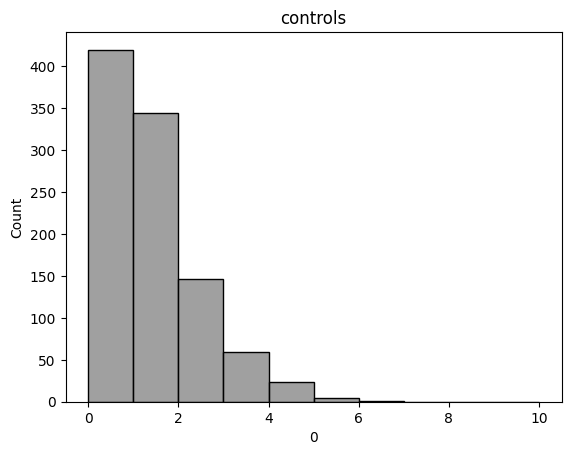

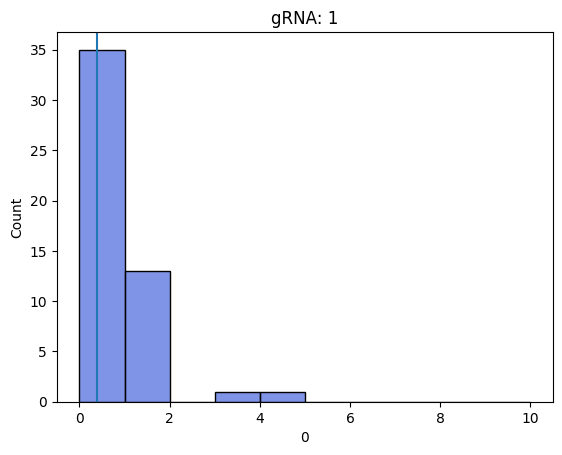

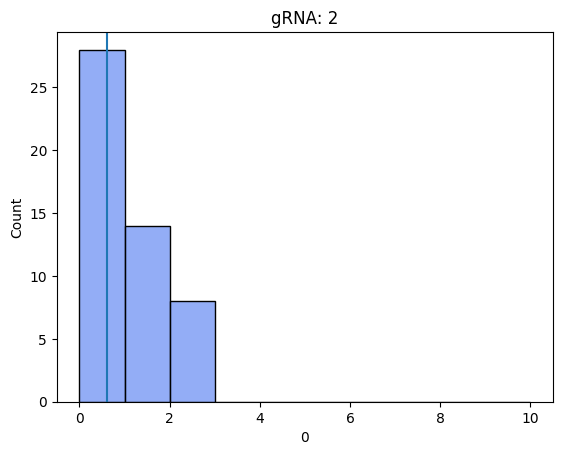

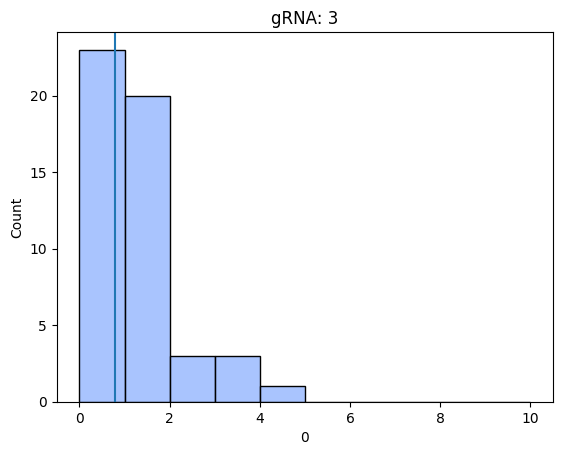

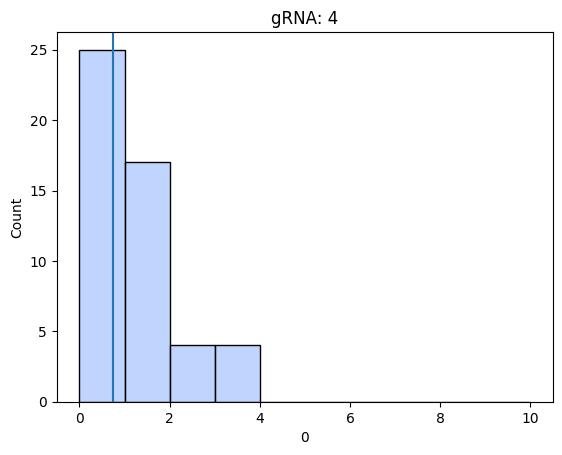

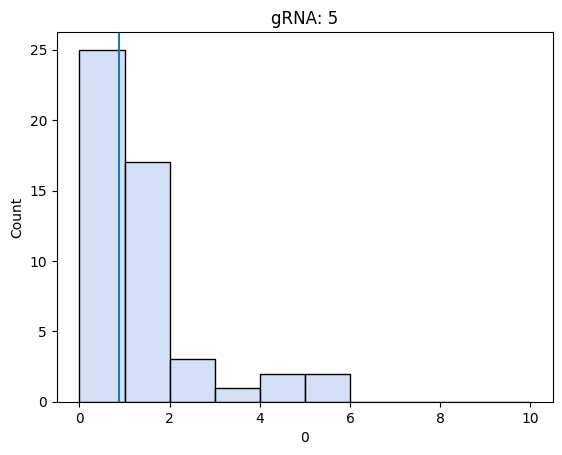

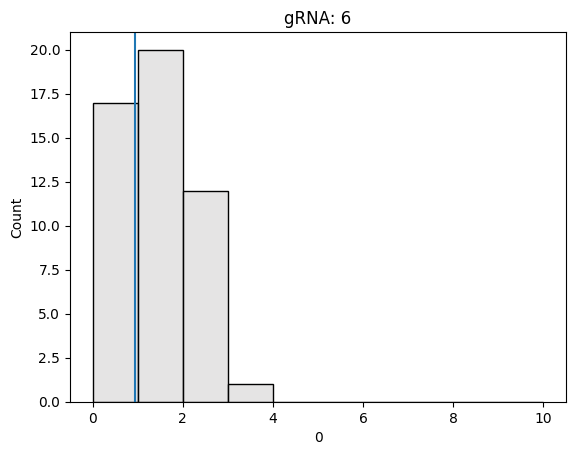

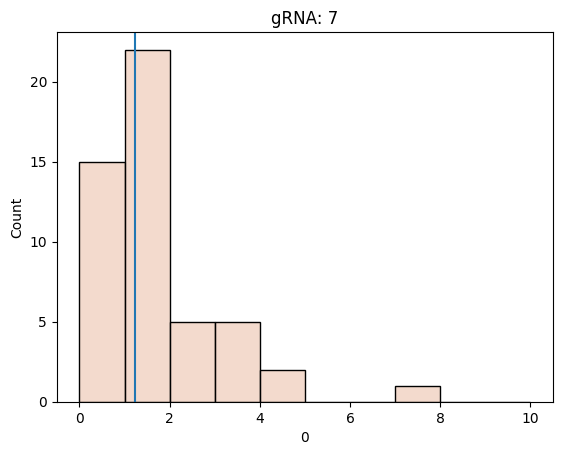

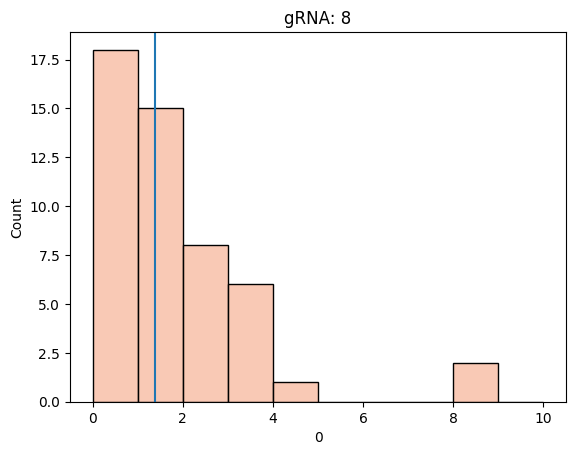

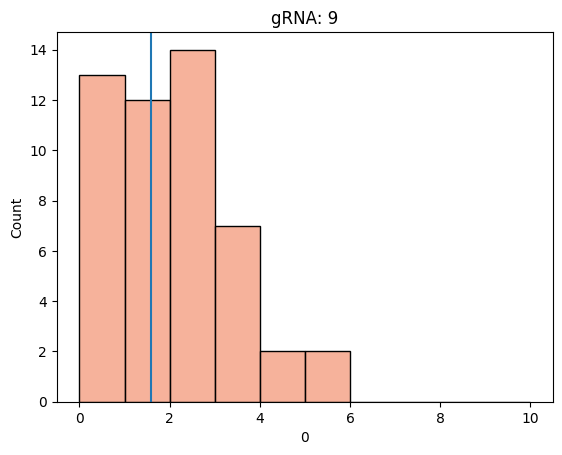

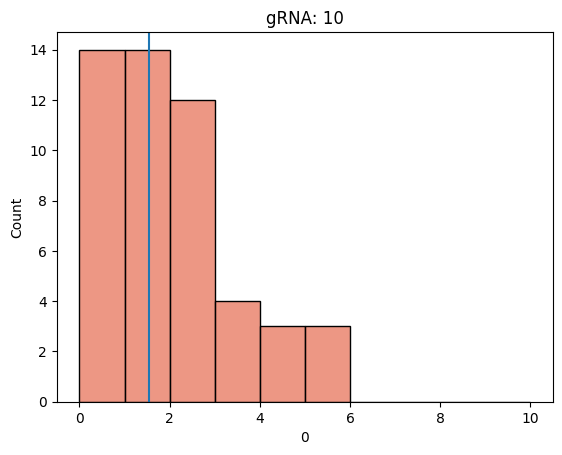

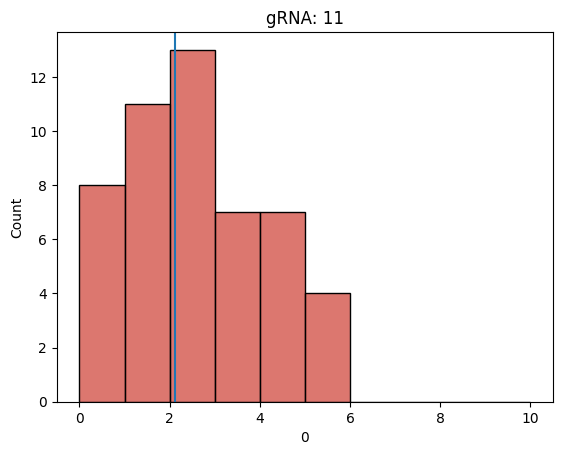

In [9]:
data_df = pd.DataFrame(gene_obs).assign(guide=guide_obs.argmax(axis=1) + (guide_obs.sum(axis=1) > 0))
# guides_df = pd.DataFrame(guide_obs, columns=[f"guide_{i}" for i in range(n_guides)])
# sampled_data = sampled_data
# gene_obs.shape
max_count = data_df.values.max()
counts_col = 0
bins = np.arange(max_count).astype(int)
plt.title("controls")
sns.histplot(data_df.query("guide==0"), x=counts_col, bins=bins, color="grey")
plt.show()
for guide in range(n_guides):
    plt.title(f"gRNA: {guide+1}")
    # plt.title(f"gRNA: {guide+1}, efficiency: {efficiency[guide]:.1f}")
    guide_data = data_df.query(f"guide=={guide+1}")
    plt.axvline(guide_data[counts_col].mean())
    sns.histplot(data_df.query(f"guide=={guide+1}"), x=counts_col, bins=bins, color=palette[guide//n_guides_per_element])
    plt.show()

# sns.ecdfplot(data_df.query("guide==0"), x=counts_col, label="control")
# for guide in range(n_guides):
#     plt.title(f"gRNA: {guide+1}")
#     guide_data = data_df.query(f"guide=={guide+1}")
#     sns.ecdfplot(guide_data, x=counts_col, label=f"gRNA: {guide+1}")
# plt.legend()
# plt.show()
# sns.histplot(sampled_data, x="gene_obs")

100%|██████████| 10000/10000 [06:17<00:00, 26.52it/s, init loss: 5144.4473, avg. loss [9501-10000]: 4976.8777]


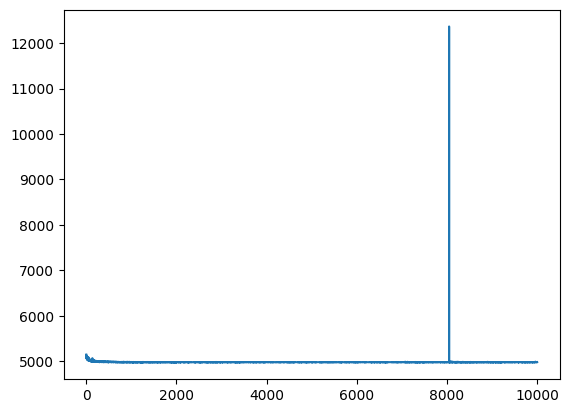

In [24]:
from numpyro.infer.autoguide import AutoDAIS, AutoNormal, init_to_median

# set model args, kwargs for inference
model_args = (gene_obs,)
model_kwargs = {
    "prior_inclusion_prob": 0.1,
    "guide_obs": guide_obs,
    "guide_target_elements": guide_target_elements,
    "non_effect_scale": 0.1,
    "efficiency": model_params["efficiency"],
    # "n_genes": n_genes,
}

# construct AutoNormal guide for model
# perturbseq_guide = perturbseq_guide_autonormal()

perturbseq_guide = AutoDAIS(
    perturbseq_model,
    # init_scale=1,
    K=32,
    # eta_max=1,
    # eta_init=0.1,
    init_loc_fn=init_to_median,
)

# perturbseq_guide = AutoNormal(
#     perturbseq_model,
#     init_loc_fn=init_to_median,
# )

svi_result = run_svi(
    model_args, model_kwargs, perturbseq_model, perturbseq_guide, random_seed=random_seed, n_steps=10000, lr=0.003
)
svi_result.params.keys()
plt.plot(svi_result.losses)

In [25]:
# unconstrained_locs = get_unconstrained_locs(svi_result)


In [26]:

# Save SVI results
predictive_svi = Predictive(perturbseq_guide, params=svi_result.params, num_samples=num_samples)
svi_posterior_samples = predictive_svi(PRNGKey(random_seed), None, **model_kwargs)
for k, v in svi_posterior_samples.items():
    print(k, v.shape)

auto_factor (1000, 0)
auto_momentum (1000, 32, 14)
auto_z_0 (1000, 14)
covariate_weights (1000, 1, 1)
dispersion (1000,)
log2_fold_change (1000, 11, 1)
mean (1000,)


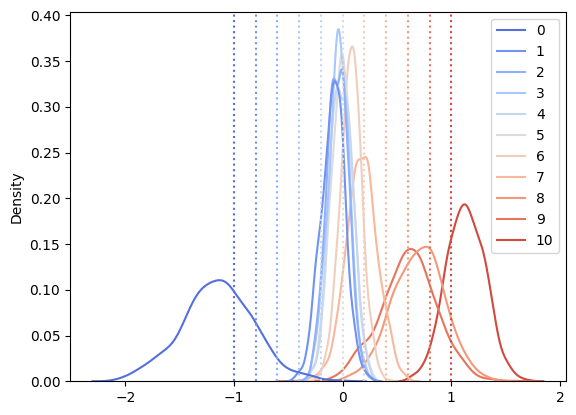

In [27]:
# lfc_df =
sns.kdeplot(svi_posterior_samples["log2_fold_change"].squeeze(), palette=palette)
for i, lfc in enumerate(log2_fc):
    plt.axvline(lfc, color=palette[i], linestyle="dotted")

In [28]:
# Save MCMC results
mcmc = run_mcmc(
    model_args,
    model_kwargs,
    perturbseq_model,
    # unconstrained_locs,
    num_samples=num_samples,
    random_seed=random_seed,
)
mcmc_posterior_samples = mcmc.get_samples()

sample: 100%|██████████| 2000/2000 [00:11<00:00, 178.00it/s, 15 steps of size 2.48e-01. acc. prob=0.94]


<Axes: >

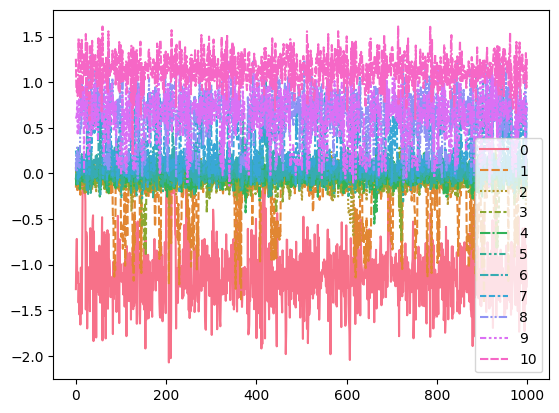

In [15]:
sns.lineplot(mcmc_posterior_samples["log2_fold_change"].squeeze())
# # Create output directories if they don't exist
# output_dir = "data/fixed_efficiency"
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)
# jnp.savez(os.path.join(output_dir, "svi"), **svi_posterior_samples)
# jnp.savez(os.path.join(output_dir, "mcmc"), **mcmc_posterior_samples)

## load results


In [29]:
# # for k in ["log2_fold_change", "mean", "dispersion"]:
# # k = "log2_fold_change"


# def get_simulation_df(data_dir, k):
#     """Read the MCMC and SVI posterior samples from data_dir and return a combined DataFrame for the key k."""
#     mcmc_file = f"{data_dir}/mcmc.npz"
#     svi_file = f"{data_dir}/svi.npz"
#     mcmc_npz = np.load(mcmc_file)
#     svi_npz = np.load(svi_file)

#     mcmc_df = pd.DataFrame({k: mcmc_npz[k].squeeze(), "method": "MCMC"})
#     svi_df = pd.DataFrame({k: svi_npz[k].squeeze(), "method": "SVI"})
#     df = pd.concat((mcmc_df, svi_df))
#     return df


# def get_efficiency_df(data_dir):
#     """Read the MCMC and SVI posterior samples from data_dir and return a combined DataFrame for the key k."""
#     mcmc_file = f"{data_dir}/mcmc.npz"
#     svi_file = f"{data_dir}/svi.npz"
#     mcmc_npz = np.load(mcmc_file)
#     svi_npz = np.load(svi_file)

#     mcmc_data = mcmc_npz["efficiency"].squeeze()
#     n_guides = mcmc_data.shape[1]
#     guide_names = [f"guide_{i+1}" for i in range(n_guides)]
#     mcmc_df = pd.DataFrame(mcmc_npz["efficiency"].squeeze(), columns=guide_names).assign(method="MCMC")
#     svi_df = pd.DataFrame(svi_npz["efficiency"].squeeze(), columns=guide_names).assign(method="SVI")
#     # mcmc_df = pd.DataFramepd.DataFrame({k: mcmc_npz[k].squeeze(), "method": "MCMC"})
#     # svi_df = pd.DataFrame({k: svi_npz[k].squeeze(), "method": "SVI"})
#     df = pd.concat((mcmc_df, svi_df))
#     return df

# lfc_df = get_simulation_df(output_dir, "log2_fold_change")

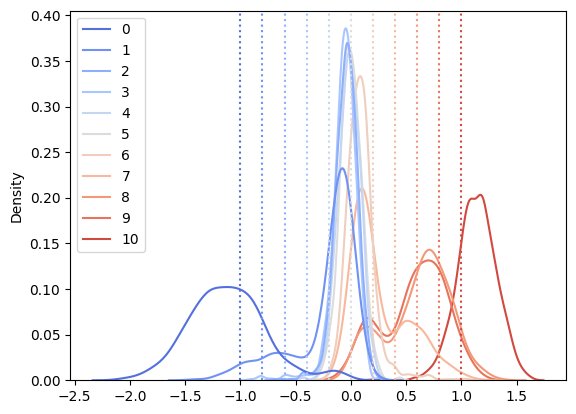

In [30]:
# lfc_df =
sns.kdeplot(mcmc_posterior_samples["log2_fold_change"].squeeze(), palette=palette)
for i, lfc in enumerate(log2_fc):
    plt.axvline(lfc, color=palette[i], linestyle="dotted")

In [38]:
np.corrcoef(mcmc_posterior_samples["log2_fold_change"].squeeze().T)

array([[ 1.        ,  0.03380714,  0.03447348,  0.04124871,  0.02286952,
         0.07324355,  0.11400887,  0.0492577 ,  0.03650837,  0.12653931,
         0.00834281],
       [ 0.03380714,  1.        , -0.08010451,  0.03521479,  0.0320577 ,
        -0.00882493,  0.04144301, -0.03984435,  0.12076721,  0.10101066,
         0.0213002 ],
       [ 0.03447348, -0.08010451,  1.        , -0.05556395, -0.04357012,
         0.02219635,  0.03981188,  0.01862883,  0.04050049,  0.06323508,
         0.03570791],
       [ 0.04124871,  0.03521479, -0.05556395,  1.        ,  0.01696759,
         0.02199308,  0.03168154,  0.07458314,  0.04868669,  0.0249929 ,
         0.06524679],
       [ 0.02286952,  0.0320577 , -0.04357012,  0.01696759,  1.        ,
         0.01010027,  0.00969664,  0.03385456,  0.0363862 ,  0.03223327,
         0.01915046],
       [ 0.07324355, -0.00882493,  0.02219635,  0.02199308,  0.01010027,
         1.        ,  0.01462539,  0.05733237,  0.00291778,  0.11687707,
         0.088

In [18]:
# dfs = []
#     output_dir = f"data/run_efficiency_{efficiency:0.1f}"
#     lfc_df = get_simulation_df(output_dir, "log2_fold_change")
#     efficiency_df = get_efficiency_df(output_dir)
# lfc_all_df = pd.concat([lfc_df.drop(columns="method"), efficiency_df], axis=1).assign(efficiency=efficiency_text)
# lfc_all_df = lfc_df.assign(efficiency=efficiency_text)
# lfc_all_df
#     dfs.append(combined_df)
# lfc_all_df = pd.concat(dfs)